# Análisis exploratorio de datos (EDA) y limpieza para modelos de recomendación en Food.com

En este primer notebook se realizará un análisis exploratorio de los datos (EDA), se limpiarán los distintos conjuntos de datos proporcionados y se prepararán para alimentar modelos de recomendación como el *Base Model*, *KNN*, *Matrix Factorization* y *Bernoulli Factorization*, entre otros.

*Autores:* [Completar]

> Nota: Para obtener más información sobre el proyecto puedes consultar el repositorio original en [GitHub](https://github.com/DiegoRecover8/Food.com-Recommender-Systems).

In [55]:
# Imports y configuración general
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import ast
import warnings

# Configuraciones de display y gráficos
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
%matplotlib inline

## Carga de datos

Se procede a cargar los distintos ficheros CSV que forman parte del dataset:

- `interactions_train.csv`, `interactions_validation.csv`, `interactions_test.csv`: interacciones de los usuarios con recetas en los tres splits.
- `RAW_recipes.csv`: información original de las recetas.
- `PP_recipes.csv`: recetas preprocesadas con tokens y técnicas de cocina.
- `PP_users.csv`: usuarios preprocesados con sus ítems y valoraciones listadas.

Antes de cargar cada archivo se verifica que exista para evitar errores.


In [57]:
# Primero cargamos los ficheros necesarios para el análisis exploratorio de datos (EDA)
DATA_DIR = Path("..") / "data" / "raw"

interactions_train = pd.read_csv(DATA_DIR / "interactions_train.csv")
interactions_validation = pd.read_csv(DATA_DIR / "interactions_validation.csv")
interactions_test = pd.read_csv(DATA_DIR / "interactions_test.csv")
raw_recipes = pd.read_csv(DATA_DIR / "RAW_recipes.csv")
pp_recipes = pd.read_csv(DATA_DIR / "PP_recipes.csv")
pp_users = pd.read_csv(DATA_DIR / "PP_users.csv")

## Funciones auxiliares

Para facilitar la limpieza y exploración de los datos se definen varias funciones auxiliares:

- **safe_literal_eval**: parsea de forma segura cadenas que representan listas u otros literales de Python.
- **summarize_dataframe**: muestra información básica de un DataFrame (dimensiones, primeras filas, valores nulos).
- **check_duplicates**: cuenta duplicados basándose en un subconjunto de columnas.
- **save_processed**: guarda un DataFrame en el directorio de datos procesados.


In [68]:
# Funciones auxiliares para carga, evaluación y guardado de datos

def safe_literal_eval(val):
    # Evalúa de forma segura una representación en cadena de una lista u otro literal de Python
    if pd.isna(val):
        return np.nan
    try:
        return ast.literal_eval(val)
    except Exception:
        return np.nan


def summarize_dataframe(df: pd.DataFrame, name: str) -> None:
    # Muestra un resumen básico de un DataFrame
    print(f"Resumen del DataFrame: {name}")
    print("Dimensiones:", df.shape)
    display(df.head())
    print(f"Valores nulos totales: {df.isnull().sum().sum()}\n")
    

def check_duplicates(df: pd.DataFrame, subset, name: str) -> int:
    # Cuenta duplicados en un subconjunto de columnas y devuelve el número de duplicados
    num_dup = df.duplicated(subset=subset).sum()
    print(f"{name} - Duplicados en {subset}: {num_dup}")
    return num_dup


def save_processed(df: pd.DataFrame, filename: str) -> None:
    # Guarda un DataFrame en el directorio de datos procesados con el nombre indicado
    path = Path("..") / "data" / "processed" / filename
    df.to_csv(path, index=False)
    print(f"Datos guardados en {path}")

## Inspección inicial de los datos

Tras cargar los datos se inspecciona cada DataFrame para comprender su estructura. Se muestran las dimensiones las primeras filas y el número de valores nulos por columna.


In [69]:
# Diccionario de datasets para inspección
datasets = {
    'interactions_train': interactions_train,
    'interactions_validation': interactions_validation,
    'interactions_test': interactions_test,
    'raw_recipes': raw_recipes,
    'pp_recipes': pp_recipes,
    'pp_users': pp_users
}

for name, df in datasets.items():
    summarize_dataframe(df, name)

Resumen del DataFrame: interactions_train
Dimensiones: (698901, 6)


,user_id,recipe_id,date,rating,u,i
0,2046,4684,2000-02-25,5.0,22095,44367
1,2046,517,2000-02-25,5.0,22095,87844
2,1773,7435,2000-03-13,5.0,24732,138181
3,1773,278,2000-03-13,4.0,24732,93054
4,2046,3431,2000-04-07,5.0,22095,101723


Valores nulos totales: 0

Resumen del DataFrame: interactions_validation
Dimensiones: (7023, 6)


,user_id,recipe_id,date,rating,u,i
0,76535,33627,2005-02-15,4.0,5,177317
1,160497,75307,2005-10-24,4.0,23,170785
2,930021,100961,2008-11-30,4.0,31,165555
3,58439,154105,2007-03-24,4.0,44,177453
4,628951,14525,2008-02-16,5.0,45,142367


Valores nulos totales: 0

Resumen del DataFrame: interactions_test
Dimensiones: (12455, 6)


...

Valores nulos totales: 4980

Resumen del DataFrame: pp_recipes
Dimensiones: (178265, 8)


,id,i,name_tokens,ingredient_tokens,steps_tokens,techniques,calorie_level,ingredient_ids
0,424415,23,"[40480, 37229, 2911, 1019, 249, 6878, 6878, 28...","[[2911, 1019, 249, 6878], [1353], [6953], [153...","[40480, 40482, 21662, 481, 6878, 500, 246, 161...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",0,"[389, 7655, 6270, 1527, 3406]"
1,146223,96900,"[40480, 18376, 7056, 246, 1531, 2032, 40481]","[[17918], [25916], [2507, 6444], [8467, 1179],...","[40480, 40482, 729, 2525, 10906, 485, 43, 8393...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",0,"[2683, 4969, 800, 5298, 840, 2499, 6632, 7022,..."
2,312329,120056,"[40480, 21044, 16954, 8294, 556, 10837, 40481]","[[5867, 24176], [1353], [6953], [1301, 11332],...","[40480, 40482, 8240, 481, 24176, 296, 1353, 66...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...",1,"[1257, 7655, 6270, 590, 5024, 1119, 4883, 6696..."
3,74301,168258,"[40480, 10025, 31156, 40481]","[[1270, 1645, 28447], [21601], [27952, 29471, ...","[40480, 40482, 5539, 21601, 1073, 903, 2324, 4...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,"[7940, 3609, 7060, 6265, 1170, 6654, 5003, 3561]"
4,76272,109030,"[40480, 17841, 252, 782, 2373, 1641, 2373, 252...","[[1430, 11434], [1430, 17027], [1615, 23, 695,...","[40480, 40482, 14046, 1430, 11434, 488, 17027,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",0,"[3484, 6324, 7594, 243]"


Valores nulos totales: 0

Resumen del DataFrame: pp_users
Dimensiones: (25076, 6)


,u,techniques,items,n_items,ratings,n_ratings
0,0,"[8, 0, 0, 5, 6, 0, 0, 1, 0, 9, 1, 0, 0, 0, 1, ...","[1118, 27680, 32541, 137353, 16428, 28815, 658...",31,"[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 4.0, 4.0, ...",31
1,1,"[11, 0, 0, 2, 12, 0, 0, 0, 0, 14, 5, 0, 0, 0, ...","[122140, 77036, 156817, 76957, 68818, 155600, ...",39,"[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, ...",39
2,2,"[13, 0, 0, 7, 5, 0, 1, 2, 1, 11, 0, 1, 0, 0, 1...","[168054, 87218, 35731, 1, 20475, 9039, 124834,...",27,"[3.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 5.0, ...",27
3,3,"[498, 13, 4, 218, 376, 3, 2, 33, 16, 591, 10, ...","[163193, 156352, 102888, 19914, 169438, 55772,...",1513,"[5.0, 5.0, 5.0, 5.0, 4.0, 4.0, 5.0, 5.0, 5.0, ...",1513
4,4,"[161, 1, 1, 86, 93, 0, 0, 11, 2, 141, 0, 16, 0...","[72857, 38652, 160427, 55772, 119999, 141777, ...",376,"[5.0, 5.0, 5.0, 5.0, 4.0, 4.0, 5.0, 4.0, 5.0, ...",376


Valores nulos totales: 0



## Validación inicial y coherencia de los datos

Se realizan algunas comprobaciones básicas antes de la limpieza:

- Búsqueda de duplicados en las interacciones.
- Rangos mínimos y máximos de valoraciones (`rating`) y fechas (`date`).
- Número de usuarios y recetas únicos en cada split.
- Consistencia de los identificadores de recetas entre las interacciones y las tablas de recetas (`RAW_recipes` y `PP_recipes`), y de los identificadores de usuarios entre interacciones y `PP_users`.


In [72]:
# Comprobación de duplicados, rangos y estadísticas básicas para interacciones
for split_name, df in {
    'train': interactions_train,
    'validation': interactions_validation,
    'test': interactions_test}.items():
    print(f"\nValidación del split {split_name}")
    check_duplicates(df, subset=['user_id', 'recipe_id', 'rating', 'date'], name=split_name)

    # Rangos de rating
    if 'rating' in df.columns:
        print(f"Rango de ratings - min: {df['rating'].min()}, max: {df['rating'].max()}")

    # Fechas
    if 'date' in df.columns:
        print(f"Rango de fechas - min: {df['date'].min()}, max: {df['date'].max()}")

    # Número de usuarios y recetas únicos
    if 'user_id' in df.columns:
        print(f"Usuarios únicos: {df['user_id'].nunique()}")
    if 'recipe_id' in df.columns:
        print(f"Recetas únicas: {df['recipe_id'].nunique()}")

# Consistencia entre identificadores de recetas
recipes_ids_raw = set(raw_recipes['id'])
recipes_ids_pp_i = set(pp_recipes['i']) if 'i' in pp_recipes.columns else set()
recipes_ids_interactions = set(interactions_train['recipe_id']) | set(interactions_validation['recipe_id']) | set(interactions_test['recipe_id'])

missing_in_raw = recipes_ids_interactions - recipes_ids_raw
print(f"\nRecetas presentes en interacciones pero no en RAW_recipes: {len(missing_in_raw)}")

missing_in_pp_i = recipes_ids_interactions - recipes_ids_pp_i
print(f"Recetas presentes en interacciones pero no en PP_recipes (columna 'i'): {len(missing_in_pp_i)}")

# Consistencia de usuarios
total_users_interactions = set(interactions_train['user_id']) | set(interactions_validation['user_id']) | set(interactions_test['user_id'])
users_pp = set(pp_users['u']) if 'u' in pp_users.columns else set()
missing_users = total_users_interactions - users_pp
print(f"Usuarios presentes en interacciones pero no en PP_users: {len(missing_users)}")


Validación del split train
train - Duplicados en ['user_id', 'recipe_id', 'rating', 'date']: 0
Rango de ratings - min: 0.0, max: 5.0
Rango de fechas - min: 2000-02-25, max: 2018-12-19
Usuarios únicos: 25076
Recetas únicas: 160901

Validación del split validation
validation - Duplicados en ['user_id', 'recipe_id', 'rating', 'date']: 0
Rango de ratings - min: 0.0, max: 5.0
Rango de fechas - min: 2000-12-06, max: 2018-12-11
Usuarios únicos: 7023
Recetas únicas: 6621

Validación del split test
test - Duplicados en ['user_id', 'recipe_id', 'rating', 'date']: 0
Rango de ratings - min: 0.0, max: 5.0
Rango de fechas - min: 2000-10-05, max: 2018-12-18
Usuarios únicos: 12455
Recetas únicas: 11695

Recetas presentes en interacciones pero no en RAW_recipes: 0
Recetas presentes en interacciones pero no en PP_recipes (columna 'i'): 96418
Usuarios presentes en interacciones pero no en PP_users: 24556


## Limpieza de interacciones

La limpieza de las tablas de interacciones se centra en:

- Convertir la columna `date` a tipo `datetime`.
- Asegurar que las valoraciones (`rating`) sean numéricas.
- Eliminar filas con valores faltantes en columnas clave (`user_id`, `recipe_id`, `rating`).
- Eliminar duplicados exactos.
- Resolver casos en los que el mismo usuario ha valorado la misma receta varias veces en un mismo split. Se conserva la interacción más reciente.

Cada split (train, validation, test) se limpia por separado para evitar *data leakage*.


In [73]:
# Función de limpieza de interacciones
def clean_interactions(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # Conversión de fechas
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
    # Conversión de rating a numérico
    if 'rating' in df.columns:
        df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
    # Eliminación de filas con valores faltantes en columnas clave
    required_cols = [col for col in ['user_id', 'recipe_id', 'rating'] if col in df.columns]
    df = df.dropna(subset=required_cols)
    # Eliminación de duplicados exactos
    df = df.drop_duplicates()
    # Conserva la interacción más reciente para cada combinación (user, recipe)
    if set(['user_id', 'recipe_id', 'date']).issubset(df.columns):
        df = df.sort_values(['user_id', 'recipe_id', 'date'])
        df = df.drop_duplicates(subset=['user_id', 'recipe_id'], keep='last')
    return df

# Limpieza de cada split de interacciones
interactions_train_clean = clean_interactions(interactions_train)
interactions_validation_clean = clean_interactions(interactions_validation)
interactions_test_clean = clean_interactions(interactions_test)

# Guardar los datos limpios
save_processed(interactions_train_clean, 'interactions_train_clean.csv')
save_processed(interactions_validation_clean, 'interactions_validation_clean.csv')
save_processed(interactions_test_clean, 'interactions_test_clean.csv')

Datos guardados en ../data/processed/interactions_train_clean.csv
Datos guardados en ../data/processed/interactions_validation_clean.csv
Datos guardados en ../data/processed/interactions_test_clean.csv


## Análisis exploratorio de interacciones

Una vez limpiadas las interacciones, se calculan estadísticas básicas y se visualizan distribuciones de interés:

- Número de usuarios, recetas e interacciones.
- Sparsity aproximada del conjunto de entrenamiento.
- Media y mediana de las valoraciones.
- Distribución de valoraciones.
- Distribución del número de interacciones por usuario.
- Distribución del número de interacciones por receta.



Estadísticas del conjunto train:
Usuarios: 25076, Recetas: 160901, Interacciones: 698901
Sparsity aproximada: 0.000173
Rating medio: 4.574, Rating mediano: 5.000

Estadísticas del conjunto validation:
Usuarios: 7023, Recetas: 6621, Interacciones: 7023
Sparsity aproximada: 0.000151
Rating medio: 4.233, Rating mediano: 5.000

Estadísticas del conjunto test:
Usuarios: 12455, Recetas: 11695, Interacciones: 12455
Sparsity aproximada: 0.000086
Rating medio: 4.213, Rating mediano: 5.000


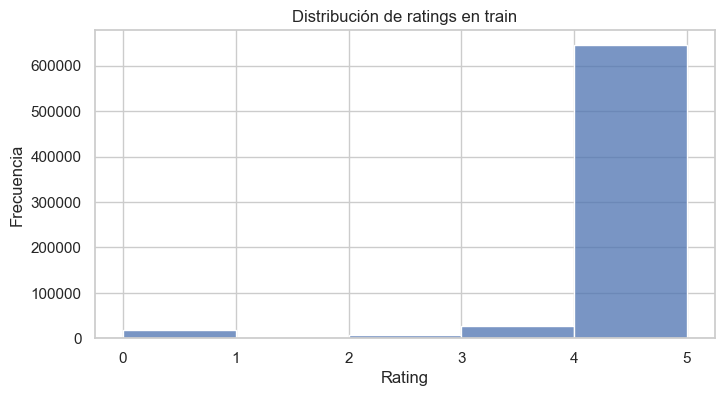

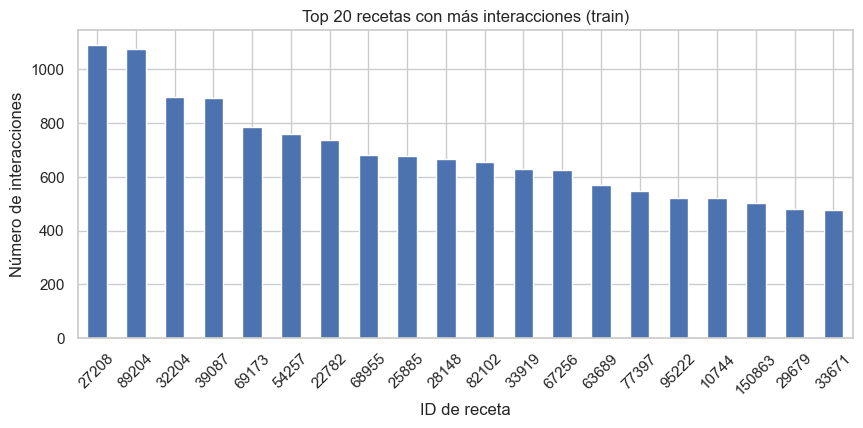

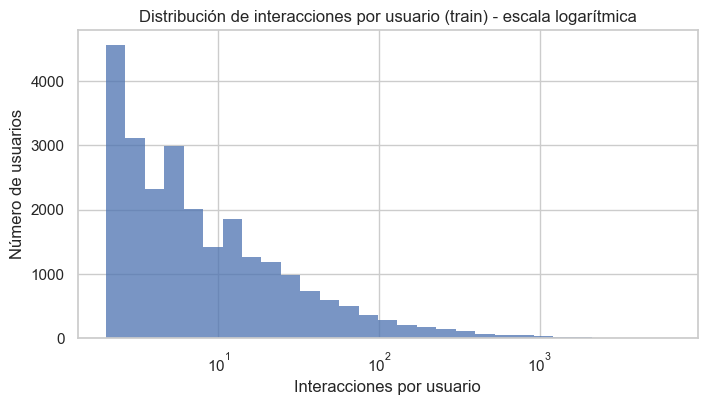

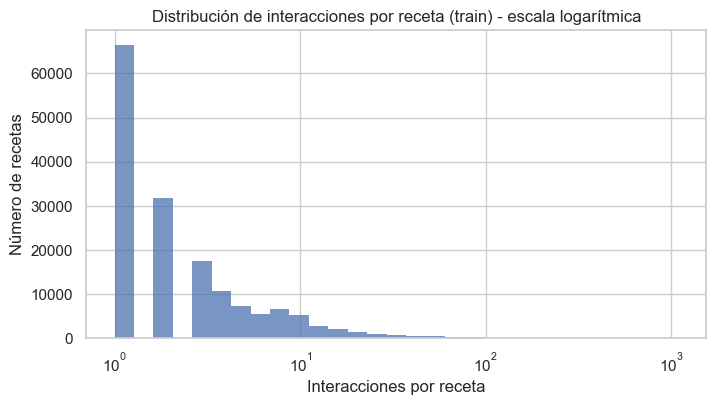

In [80]:
# Función para calcular estadísticas de un dataset de interacciones
def interactions_stats(df: pd.DataFrame, name: str) -> None:
    num_users = df['user_id'].nunique() if 'user_id' in df.columns else np.nan
    num_recipes = df['recipe_id'].nunique() if 'recipe_id' in df.columns else np.nan
    num_interactions = len(df)
    sparsity = num_interactions / (num_users * num_recipes) if num_users and num_recipes else np.nan
    avg_rating = df['rating'].mean() if 'rating' in df.columns else np.nan
    median_rating = df['rating'].median() if 'rating' in df.columns else np.nan
    print(f"\nEstadísticas del conjunto {name}:")
    print(f"Usuarios: {num_users}, Recetas: {num_recipes}, Interacciones: {num_interactions}")
    print(f"Sparsity aproximada: {sparsity:.6f}")
    print(f"Rating medio: {avg_rating:.3f}, Rating mediano: {median_rating:.3f}")

# Calcular estadísticas para cada split limpio
interactions_stats(interactions_train_clean, 'train')
interactions_stats(interactions_validation_clean, 'validation')
interactions_stats(interactions_test_clean, 'test')

# Distribución de ratings en el conjunto de entrenamiento
plt.figure(figsize=(8, 4))
sns.histplot(interactions_train_clean['rating'], bins=5, kde=False)
plt.title('Distribución de ratings en train')
plt.xlabel('Rating')
plt.ylabel('Frecuencia')
plt.show()

# Top 20 recetas con más interacciones
top_recipes = interactions_train_clean['recipe_id'].value_counts().head(20)
plt.figure(figsize=(10, 4))
top_recipes.plot(kind='bar')
plt.title('Top 20 recetas con más interacciones (train)')
plt.xlabel('ID de receta')
plt.ylabel('Número de interacciones')
plt.xticks(rotation=45)
plt.show()

# Distribución del número de interacciones por usuario
user_counts = interactions_train_clean['user_id'].value_counts()
plt.figure(figsize=(8, 4))
sns.histplot(user_counts, bins=np.logspace(np.log10(user_counts.min()), np.log10(user_counts.max()), 30), kde=False)
plt.xscale('log')
plt.title('Distribución de interacciones por usuario (train) - escala logarítmica')
plt.xlabel('Interacciones por usuario')
plt.ylabel('Número de usuarios')
plt.show()

# Distribución del número de interacciones por receta
recipe_counts = interactions_train_clean['recipe_id'].value_counts()
plt.figure(figsize=(8, 4))
sns.histplot(recipe_counts, bins=np.logspace(np.log10(recipe_counts.min()), np.log10(recipe_counts.max()), 30), kde=False)
plt.xscale('log')
plt.title('Distribución de interacciones por receta (train) - escala logarítmica')
plt.xlabel('Interacciones por receta')
plt.ylabel('Número de recetas')
plt.show()


## Preparación de datos para modelos implícitos (Bernoulli Factorization)

Para modelos que trabajan con feedback implícito o binario, es útil transformar las valoraciones en una variable indicadora *liked* que marque si la interacción fue positiva. Se define la siguiente regla:

- `liked = 1` si el rating es mayor o igual que 4.
- `liked = 0` si el rating es menor que 4.

A continuación se crea y guarda una versión binarizada del conjunto de entrenamiento.


In [81]:
# Crear versión binaria del conjunto de entrenamiento limpio
interactions_train_implicit = interactions_train_clean.copy()
interactions_train_implicit['liked'] = (interactions_train_implicit['rating'] >= 4).astype(int)

# Seleccionar columnas relevantes para el modelo binario
cols_to_keep = [col for col in ['user_id', 'recipe_id', 'u', 'i', 'liked', 'date'] if col in interactions_train_implicit.columns]
interactions_train_implicit = interactions_train_implicit[cols_to_keep]

# Guardar el conjunto binario
save_processed(interactions_train_implicit, 'interactions_train_implicit.csv')

Datos guardados en ../data/processed/interactions_train_implicit.csv


## Limpieza y análisis de recetas (RAW_recipes)

El conjunto `RAW_recipes` contiene metadatos de las recetas en formato textual y numérico. Se llevan a cabo las siguientes acciones de limpieza:

- Convertir la columna `submitted` a formato `datetime`.
- Parsear las columnas con listas (`tags`, `nutrition`, `steps`, `ingredients`) usando `safe_literal_eval`.
- Extraer de la columna `nutrition` las variables nutricionales (`calories`, `total_fat`, `sugar`, `sodium`, `protein`, `saturated_fat`, `carbohydrates`).
- Limpiar el texto en `name` y `description` (quitar espacios y reemplazar cadenas vacías por `NaN`).
- Calcular estadísticas básicas sobre tiempos de preparación (`minutes`), número de pasos (`n_steps`) y número de ingredientes (`n_ingredients`).


In [82]:
# Trabajar sobre una copia para no modificar el original
recipes_clean = raw_recipes.copy()

# Conversión de fecha en 'submitted'
if 'submitted' in recipes_clean.columns:
    recipes_clean['submitted'] = pd.to_datetime(recipes_clean['submitted'], errors='coerce')

# Parsear columnas serializadas
to_parse = ['tags', 'nutrition', 'steps', 'ingredients']
for col in to_parse:
    if col in recipes_clean.columns:
        recipes_clean[col] = recipes_clean[col].apply(safe_literal_eval)

# Extraer información nutricional si la columna 'nutrition' tiene la longitud adecuada
nutrition_cols = ['calories', 'total_fat', 'sugar', 'sodium', 'protein', 'saturated_fat', 'carbohydrates']

if 'nutrition' in recipes_clean.columns:
    def extract_nutrition(row):
        if isinstance(row, list) and len(row) == 7:
            return pd.Series(row)
        else:
            return pd.Series([np.nan] * 7)
    recipes_clean[nutrition_cols] = recipes_clean['nutrition'].apply(extract_nutrition)

# Limpieza de texto
if 'name' in recipes_clean.columns:
    recipes_clean['name'] = recipes_clean['name'].astype(str).str.strip()
if 'description' in recipes_clean.columns:
    recipes_clean['description'] = recipes_clean['description'].astype(str).str.strip()
    recipes_clean['description'] = recipes_clean['description'].replace('', np.nan)

# Estadísticas básicas de columnas numéricas
for col in ['minutes', 'n_steps', 'n_ingredients']:
    if col in recipes_clean.columns:
        print(f"Resumen de {col}:")
        print(recipes_clean[col].describe())

# Guardar recetas limpias
save_processed(recipes_clean, 'recipes_clean.csv')

Resumen de minutes:
count    2.316370e+05
mean     9.398546e+03
std      4.461963e+06
min      0.000000e+00
25%      2.000000e+01
50%      4.000000e+01
75%      6.500000e+01
max      2.147484e+09
Name: minutes, dtype: float64
Resumen de n_steps:
count    231637.000000
mean          9.765499
std           5.995128
min           0.000000
25%           6.000000
50%           9.000000
75%          12.000000
max         145.000000
Name: n_steps, dtype: float64
Resumen de n_ingredients:
count    231637.000000
mean          9.051153
std           3.734796
min           1.000000
25%           6.000000
50%           9.000000
75%          11.000000
max          43.000000
Name: n_ingredients, dtype: float64
Datos guardados en ../data/processed/recipes_clean.csv


## Limpieza y análisis de recetas preprocesadas (PP_recipes)

El archivo `PP_recipes` incluye representaciones tokenizadas de nombres, ingredientes, pasos y técnicas culinarias, así como un identificador alternativo (`i`). Se procede a:

- Parsear columnas serializadas (`name_tokens`, `ingredient_tokens`, `steps_tokens`, `techniques`, `ingredient_ids`).
- Evaluar la correspondencia entre `id` e `i` y su relación con `RAW_recipes`.
- Unir, cuando sea posible, la información de `PP_recipes` con las variables nutricionales extraídas de `RAW_recipes`.


In [83]:
# Trabajar sobre una copia
tmp_pp_recipes = pp_recipes.copy()

# Parsear columnas serializadas
to_parse_pp = ['name_tokens', 'ingredient_tokens', 'steps_tokens', 'techniques', 'ingredient_ids']
for col in to_parse_pp:
    if col in tmp_pp_recipes.columns:
        tmp_pp_recipes[col] = tmp_pp_recipes[col].apply(safe_literal_eval)

# Verificar correspondencia entre 'id' e 'i'
if {'id', 'i'}.issubset(tmp_pp_recipes.columns):
    mismatch_ids = (tmp_pp_recipes['id'] != tmp_pp_recipes['i']).sum()
    print(f"Registros donde 'id' y 'i' no coinciden: {mismatch_ids}")

# Intentar unir con información nutricional de recipes_clean
if 'id' in tmp_pp_recipes.columns and 'id' in recipes_clean.columns:
    pp_recipes_features = tmp_pp_recipes.merge(
        recipes_clean[['id'] + nutrition_cols],
        on='id',
        how='left'
    )
    # Métricas de cobertura
    cobertura = pp_recipes_features[nutrition_cols].notna().any(axis=1).mean()
    print(f"Cobertura de información nutricional tras la unión: {cobertura:.2%}")
else:
    pp_recipes_features = tmp_pp_recipes.copy()

# Guardar dataset combinado
to_save_pp = 'recipes_features_clean.csv' if not pp_recipes_features.empty else 'pp_recipes_clean.csv'
save_processed(pp_recipes_features, to_save_pp)

Registros donde 'id' y 'i' no coinciden: 178265
Cobertura de información nutricional tras la unión: 100.00%
Datos guardados en ../data/processed/recipes_features_clean.csv


## Limpieza y análisis de usuarios preprocesados (PP_users)

`PP_users` contiene listas de ítems y valoraciones por usuario, además de técnicas culinarias asociadas. Se realiza:

- Parseo seguro de las columnas serializadas (`techniques`, `items`, `ratings`).
- Validación de que `n_items` y `n_ratings` coinciden con la longitud de las listas.
- Cálculo de estadísticas básicas sobre usuarios e interacciones almacenadas en este archivo.


In [84]:
# Copiar para no modificar el original
users_clean = pp_users.copy()

# Parsear columnas serializadas
cols_to_parse_users = ['techniques', 'items', 'ratings']
for col in cols_to_parse_users:
    if col in users_clean.columns:
        users_clean[col] = users_clean[col].apply(safe_literal_eval)

# Validar longitud de listas vs columnas n_items y n_ratings
if {'items', 'n_items'}.issubset(users_clean.columns):
    users_clean['len_items'] = users_clean['items'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    mismatch_items = (users_clean['len_items'] != users_clean['n_items']).sum()
    print(f"Usuarios con discrepancia entre n_items y longitud de items: {mismatch_items}")

if {'ratings', 'n_ratings'}.issubset(users_clean.columns):
    users_clean['len_ratings'] = users_clean['ratings'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    mismatch_ratings = (users_clean['len_ratings'] != users_clean['n_ratings']).sum()
    print(f"Usuarios con discrepancia entre n_ratings y longitud de ratings: {mismatch_ratings}")

# Estadísticas básicas
total_users = len(users_clean)
print(f"Número total de usuarios en PP_users: {total_users}")
if 'ratings' in users_clean.columns:
    ratings_per_user = users_clean['ratings'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    print(f"Media de valoraciones por usuario (PP_users): {ratings_per_user.mean():.2f}")

# Guardar usuarios limpios
save_processed(users_clean, 'users_clean.csv')

Usuarios con discrepancia entre n_items y longitud de items: 0
Usuarios con discrepancia entre n_ratings y longitud de ratings: 0
Número total de usuarios en PP_users: 25076
Media de valoraciones por usuario (PP_users): 27.87
Datos guardados en ../data/processed/users_clean.csv


## Validaciones de consistencia entre datasets

Se comprueba la coherencia entre los distintos datasets después de la limpieza:

- Verificar que todos los usuarios y recetas de los conjuntos de validación y test aparecen también en el conjunto de entrenamiento (diagnóstico de cobertura, no filtrado).
- Evaluar la cobertura de información nutricional y tokenizada tras las uniones realizadas.

Estas validaciones ayudan a anticipar posibles problemas de cobertura cuando se entrenen los modelos de recomendación. No se deben realizar filtrados en `validation` y `test` basados en información de `train` para evitar *data leakage*.


In [85]:
# Cobertura de usuarios y recetas en validation/test respecto a train
train_users = set(interactions_train_clean['user_id'])
train_recipes = set(interactions_train_clean['recipe_id'])

for split_name, df in {'validation': interactions_validation_clean, 'test': interactions_test_clean}.items():
    users_split = set(df['user_id'])
    recipes_split = set(df['recipe_id'])
    missing_users = users_split - train_users
    missing_recipes = recipes_split - train_recipes
    print(f"Cobertura en {split_name}: usuarios no presentes en train = {len(missing_users)}, recetas no presentes en train = {len(missing_recipes)}")

# Información nutricional faltante en recipes_clean
gaps_nutrition = recipes_clean[nutrition_cols].isnull().any(axis=1).mean()
print(f"Proporción de recetas sin información nutricional completa: {gaps_nutrition:.2%}")

Cobertura en validation: usuarios no presentes en train = 0, recetas no presentes en train = 6621
Cobertura en test: usuarios no presentes en train = 0, recetas no presentes en train = 11695
Proporción de recetas sin información nutricional completa: 0.00%


## Visualizaciones finales

Por último, se incluyen algunas visualizaciones adicionales que ayudan a entender mejor la distribución de distintas variables del conjunto de recetas:

- **Distribución de minutos de preparación**: se utiliza una escala logarítmica debido a la presencia de valores extremos.
- **Relación entre número de ingredientes y número de pasos**: permite observar recetas complejas frente a sencillas.
- **Distribución de calorías**: basada en la variable `calories` extraída del campo de nutrición.


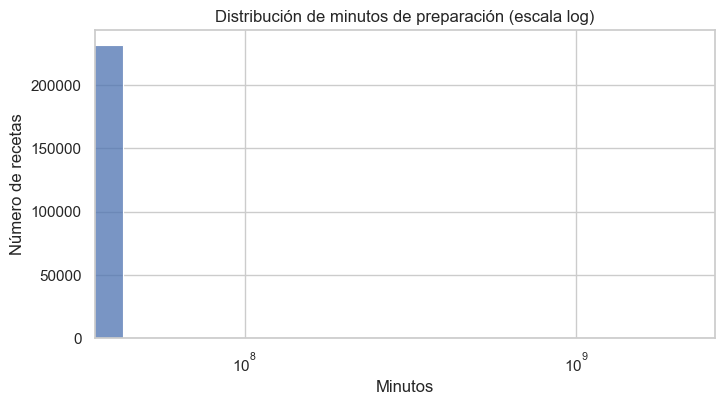

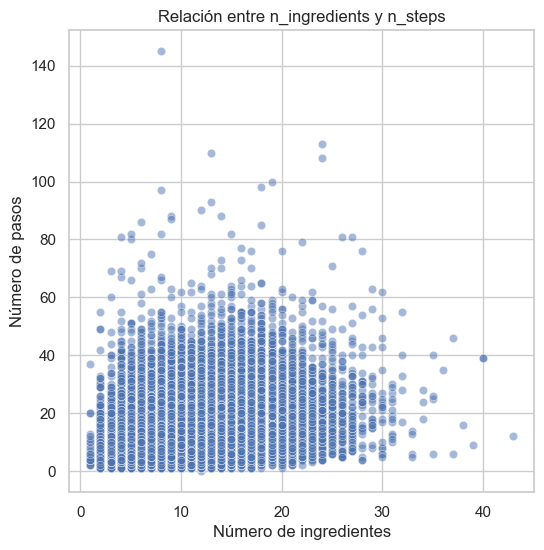

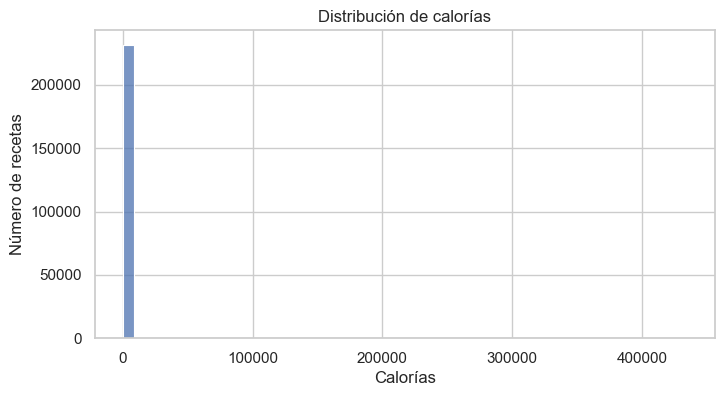

In [86]:
# Distribución de minutos de preparación
aif = 'minutes'
if 'minutes' in recipes_clean.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(recipes_clean['minutes'], bins=50)
    plt.yscale('linear')
    plt.xscale('log')
    plt.title('Distribución de minutos de preparación (escala log)')
    plt.xlabel('Minutos')
    plt.ylabel('Número de recetas')
    plt.show()

# Relación entre número de ingredientes y número de pasos
if {'n_ingredients', 'n_steps'}.issubset(recipes_clean.columns):
    plt.figure(figsize=(6, 6))
    sns.scatterplot(data=recipes_clean, x='n_ingredients', y='n_steps', alpha=0.5)
    plt.title('Relación entre n_ingredients y n_steps')
    plt.xlabel('Número de ingredientes')
    plt.ylabel('Número de pasos')
    plt.show()

# Distribución de calorías
aif = 'calories'
if 'calories' in recipes_clean.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(recipes_clean['calories'], bins=50)
    plt.title('Distribución de calorías')
    plt.xlabel('Calorías')
    plt.ylabel('Número de recetas')
    plt.show()
